# Monotonic effects

When a predictor is **ordered but the spacing between adjacent levels is not meaningful**, the two obvious encodings both have problems:

* Treating it as numeric forces the effect to be linear in the codes ($0, 1, 2, \ldots$), which is rarely defensible.
* Treating it as a regular categorical predictor ignores the ordering and spends $K - 1$ independent dummy coefficients.

Bambi's `mo()` term, ported from the R package [brms](https://paulbuerkner.com/brms/), splits the difference. It enforces monotonicity in the effect but lets the *shape* of the step-by-step change be inferred from the data. The construction follows Bürkner and Charpentier (2020).

The contribution of a monotonic predictor with $K$ levels to the linear predictor at observation $n$ is

$$
\eta_n \;=\; b \cdot D \cdot \sum_{i=1}^{x_n} \zeta_i
$$

where

* $b$ is a scalar **slope**.
* $\zeta = (\zeta_1, \ldots, \zeta_D)$ is a length-$D$ **simplex** ($\zeta_i \geq 0$, $\sum_i \zeta_i = 1$) with $D = K - 1$. Each $\zeta_i$ represents the *relative* size of the step from level $i-1$ to level $i$.
* $D$ rescales the cumulative sum so that the contribution at the highest level is exactly $b$. Practically, this lets us interpret $b$ as the total effect from the lowest to the highest level.

By default, $\zeta \sim \text{Dirichlet}(1, \ldots, 1)$ (uniform on the simplex). Together, $b$ and $\zeta$ require just two parameters per monotonic term regardless of how many levels the predictor has.

In this notebook we walk through:

1. A basic main-effect example with an ordered categorical predictor.
2. Why neither numeric nor categorical encoding works as well.
3. Integer-valued monotonic predictors (e.g. Likert items).
4. Customizing the Dirichlet prior on the simplex.
5. Sharing a simplex across `mo()` terms via `id=` (conditional monotonicity).
6. Interactions, like `mo(income) * x`.
7. Group-specific monotonic effects, `(mo(x) | g)`.

In [1]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import bambi as bmb
from bambi.interpret import plot_predictions

warnings.simplefilter("ignore", category=FutureWarning)
warnings.simplefilter("ignore", category=UserWarning)

rng = np.random.default_rng(seed=20260522)

## 1. A basic example

We replicate the brms vignette setup. An ordered factor `income` has four brackets, and the response `ls` (life satisfaction) has bracket means **30, 60, 70, 75**. The relationship is monotonically increasing but the spacing is far from linear in the codes: the jumps from bracket to bracket are 30, 10, 5.

In [2]:
levels = ["below_20", "20_to_40", "40_to_100", "greater_100"]
true_means = {
    "below_20": 30.0,
    "20_to_40": 60.0,
    "40_to_100": 70.0,
    "greater_100": 75.0,
}

n = 400
income = pd.Categorical(
    rng.choice(levels, n), categories=levels, ordered=True
)
ls = np.array([true_means[i] for i in income]) + rng.normal(0, 7, n)
data = pd.DataFrame({"ls": ls, "income": income})

data.head()

,ls,income
0,64.075493,greater_100
1,68.205670,greater_100
2,54.297501,20_to_40
3,68.794151,40_to_100
4,59.226461,20_to_40


Visualize the data. The bracket-by-bracket means highlight the strongly non-linear spacing.

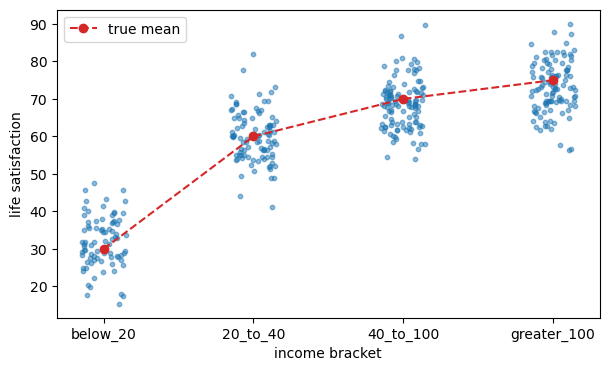

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(
    [levels.index(i) + rng.uniform(-0.15, 0.15) for i in data["income"]],
    data["ls"],
    s=10,
    alpha=0.5,
    color="C0",
)
ax.plot(
    range(len(levels)),
    [true_means[lvl] for lvl in levels],
    color="C3",
    marker="o",
    linestyle="--",
    label="true mean",
)
ax.set_xticks(range(len(levels)))
ax.set_xticklabels(levels)
ax.set_xlabel("income bracket")
ax.set_ylabel("life satisfaction")
ax.legend();

### Fitting the model

`mo()` is a stateful transform inside the model formula. It accepts integer or ordered categorical predictors. Here we let Bambi pick default priors: a `Dirichlet(1, 1, 1)` for the simplex and an auto-scaled Normal for the slope.

In [4]:
model = bmb.Model("ls ~ mo(income)", data)
model

       Formula: ls ~ mo(income)
        Family: gaussian
          Link: mu = identity
  Observations: 400
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 60.3258, sigma: 41.3132)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 16.5253)

In [5]:
idata = model.fit(
    draws=1000,
    tune=1000,
    chains=4,
    random_seed=20260522,
    progressbar=False,
    idata_kwargs={"log_likelihood": True},
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, mo(income)_simplex, mo(income)_slope]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


The posterior shows two new variables: `mo(income)_slope` (the scalar slope) and `mo(income)_simplex` (a length-3 Dirichlet simplex). Their traces look healthy.

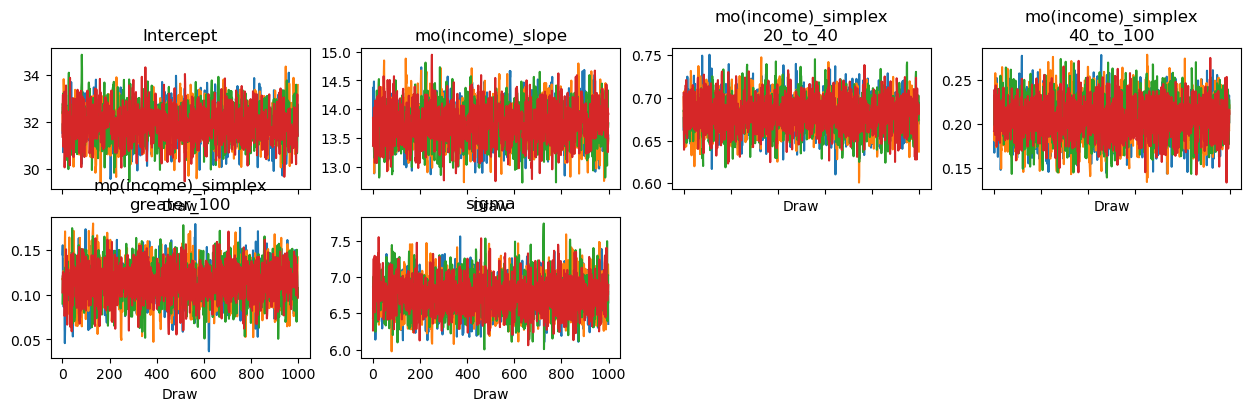

In [6]:
az.plot_trace(
    idata,
    var_names=["Intercept", "mo(income)_slope", "mo(income)_simplex", "sigma"],
);

In [7]:
az.summary(
    idata,
    var_names=["Intercept", "mo(income)_slope", "mo(income)_simplex", "sigma"],
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,31.93,0.74,31,33,2188,2263,1.00,0.016,0.011
mo(income)_slope,13.75,0.33,13,14,2216,2423,1.00,0.0071,0.005
mo(income)_simplex[20_to_40],0.6813,0.02,0.65,0.71,3988,2557,1.00,0.00032,0.00023
mo(income)_simplex[40_to_100],0.2064,0.0227,0.17,0.24,4336,2888,1.00,0.00035,0.00024
mo(income)_simplex[greater_100],0.1123,0.0203,0.08,0.14,3344,2240,1.00,0.00035,0.00026
sigma,6.744,0.244,6.4,7.1,3404,2800,1.00,0.0042,0.0031


The simplex posterior recovers the unequal spacing of the bracket means. The first step is large (about 0.67 of the total range), the middle moderate (about 0.22), and the last small (about 0.11). The slope `b` lands at the per-step *average* increase, around $(75 - 30) / 3 = 15$.

### Reconstructing the bracket means

The fitted mean at bracket $k$ is

$$
\mu_k = \alpha + b \cdot D \cdot \sum_{i=1}^{k} \zeta_i
$$

which is what `Model.predict` returns when we pass one row per bracket.

In [8]:
new_df = pd.DataFrame(
    {"income": pd.Categorical(levels, categories=levels, ordered=True)}
)
preds = model.predict(
    idata, kind="response_params", data=new_df, inplace=False
)
mu_post = preds.posterior["mu"]
fitted_summary = pd.DataFrame(
    {
        "level": levels,
        "true_mean": [true_means[l] for l in levels],
        "fitted_mean": mu_post.mean(("chain", "draw")).to_numpy().round(2),
        "lower_94": mu_post.quantile(0.03, ("chain", "draw")).to_numpy().round(2),
        "upper_94": mu_post.quantile(0.97, ("chain", "draw")).to_numpy().round(2),
    }
)
fitted_summary

,level,true_mean,fitted_mean,lower_94,upper_94
0,below_20,30.0,31.93,30.55,33.33
1,20_to_40,60.0,60.02,58.78,61.32
2,40_to_100,70.0,68.53,67.31,69.73
3,greater_100,75.0,73.17,71.96,74.36


And a visual check:

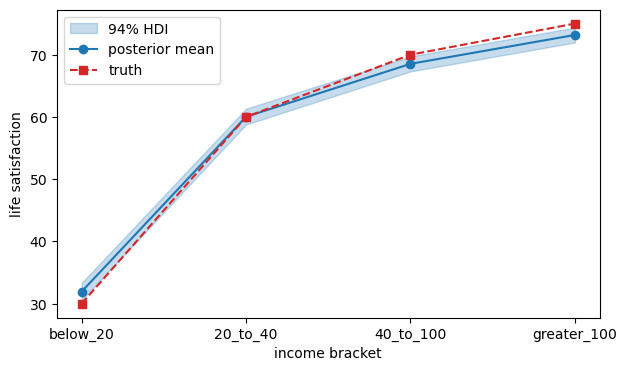

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
xs = np.arange(len(levels))
lower = mu_post.quantile(0.03, ("chain", "draw")).to_numpy()
upper = mu_post.quantile(0.97, ("chain", "draw")).to_numpy()
ax.fill_between(xs, lower, upper, color="C0", alpha=0.25, label="94% HDI")
ax.plot(xs, mu_post.mean(("chain", "draw")).to_numpy(),
        color="C0", marker="o", label="posterior mean")
ax.plot(xs, [true_means[lvl] for lvl in levels],
        color="C3", marker="s", linestyle="--", label="truth")
ax.set_xticks(xs)
ax.set_xticklabels(levels)
ax.set_xlabel("income bracket")
ax.set_ylabel("life satisfaction")
ax.legend();

## 2. Comparison with numeric and categorical encodings

Fit two alternative models on the same data:

* `ls ~ income_code` treats the four levels as evenly spaced numbers $0, 1, 2, 3$. This is the most restrictive encoding because it forces a linear effect.
* `ls ~ C(income)` uses three independent dummy coefficients. This is the most flexible encoding: each bracket gets its own mean, but the ordering information is lost.

The monotonic model sits in between: it imposes the ordering constraint but otherwise lets the bracket means take any monotone shape.

In [10]:
data["income_code"] = data["income"].cat.codes.astype(float)

model_num = bmb.Model("ls ~ income_code", data)
idata_num = model_num.fit(
    draws=1000, tune=1000, chains=4, random_seed=20260522, progressbar=False,
    idata_kwargs={"log_likelihood": True},
)

model_cat = bmb.Model("ls ~ C(income)", data)
idata_cat = model_cat.fit(
    draws=1000, tune=1000, chains=4, random_seed=20260522, progressbar=False,
    idata_kwargs={"log_likelihood": True},
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, income_code]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, C(income)]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Compare via leave-one-out cross-validation. We expect the monotonic and fully categorical models to be statistically indistinguishable here (the true mean structure satisfies the monotonicity constraint *and* it is unconstrained beyond that). The numeric encoding should lag behind because it cannot represent uneven spacing.

In [11]:
az.compare(
    {"numeric": idata_num, "categorical": idata_cat, "monotonic": idata}
)

,rank,elpd,p,elpd_diff,weight,se,dse,warning
monotonic,0,-1330.0,5.0,0.0,1.0,15.0,0.0,False
categorical,1,-1330.0,5.0,-0.0,0.0,15.0,0.1,False
numeric,2,-1450.0,3.0,-120.0,0.0,14.0,12.0,False


The categorical and monotonic models tie on `elpd_loo`, and both clearly beat the numeric encoding. The monotonic model achieves the same fit with **two** parameters where the categorical model uses **three**, and the gap grows quickly with $K$: a 10-level Likert item would need 9 dummies but still just 2 parameters with `mo()`.

We can also see the difference visually.

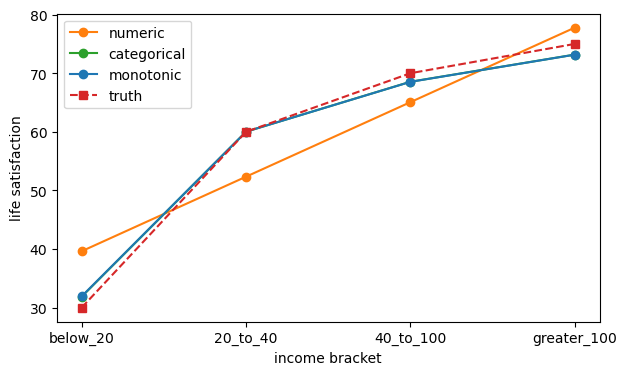

In [12]:
fitted_num = model_num.predict(
    idata_num,
    kind="response_params",
    data=new_df.assign(income_code=np.arange(4, dtype=float)),
    inplace=False,
).posterior["mu"]
fitted_cat = model_cat.predict(
    idata_cat, kind="response_params", data=new_df, inplace=False
).posterior["mu"]

fig, ax = plt.subplots(figsize=(7, 4))
xs = np.arange(len(levels))
ax.plot(xs, fitted_num.mean(("chain", "draw")).to_numpy(),
        color="C1", marker="o", label="numeric")
ax.plot(xs, fitted_cat.mean(("chain", "draw")).to_numpy(),
        color="C2", marker="o", label="categorical")
ax.plot(xs, mu_post.mean(("chain", "draw")).to_numpy(),
        color="C0", marker="o", label="monotonic")
ax.plot(xs, [true_means[lvl] for lvl in levels],
        color="C3", marker="s", linestyle="--", label="truth")
ax.set_xticks(xs)
ax.set_xticklabels(levels)
ax.set_xlabel("income bracket")
ax.set_ylabel("life satisfaction")
ax.legend();

The numeric line is forced to be straight, so it overshoots the lower brackets and undershoots the higher ones. The categorical and monotonic fits sit on top of each other.

## 3. Integer predictors

`mo()` also accepts integer-valued predictors. Think of Likert-style items or dose levels. The level codes are taken to be the sorted unique integers in the data.

In [13]:
n_int = 300
dose = rng.integers(1, 6, n_int)  # 1, 2, 3, 4, 5
# Doubly non-linear response: small effect at 1->2, then big jumps
effects = np.array([0.0, 1.0, 4.0, 7.0, 8.0])
y_int = 2.0 + effects[dose - 1] + rng.normal(0, 1.0, n_int)
df_int = pd.DataFrame({"y": y_int, "dose": dose})

model_int = bmb.Model("y ~ mo(dose)", df_int)
idata_int = model_int.fit(
    draws=1000, tune=1000, chains=4, random_seed=20260522, progressbar=False
)

az.summary(
    idata_int,
    var_names=["Intercept", "mo(dose)_slope", "mo(dose)_simplex", "sigma"],
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, mo(dose)_simplex, mo(dose)_slope]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,2.015,0.126,1.8,2.2,1782,2105,1.00,0.003,0.0021
mo(dose)_slope,2.014,0.046,1.9,2.1,1760,2316,1.00,0.0011,0.00078
mo(dose)_simplex[2],0.125,0.0212,0.092,0.16,1547,1927,1.01,0.00054,0.00039
mo(dose)_simplex[3],0.363,0.0233,0.33,0.4,2213,2567,1.00,0.0005,0.00036
mo(dose)_simplex[4],0.3916,0.0233,0.35,0.43,3088,2967,1.00,0.00042,0.00029
mo(dose)_simplex[5],0.12,0.0212,0.086,0.15,3224,2433,1.00,0.00037,0.00026
sigma,0.983,0.04,0.92,1,3124,2480,1.00,0.00072,0.00053


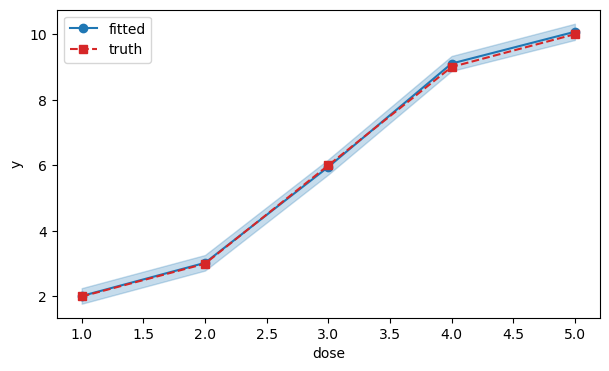

In [14]:
new_doses = pd.DataFrame({"dose": np.arange(1, 6)})
preds_int = model_int.predict(
    idata_int, kind="response_params", data=new_doses, inplace=False
).posterior["mu"]

fig, ax = plt.subplots(figsize=(7, 4))
mu_mean = preds_int.mean(("chain", "draw")).to_numpy()
lo = preds_int.quantile(0.03, ("chain", "draw")).to_numpy()
hi = preds_int.quantile(0.97, ("chain", "draw")).to_numpy()
ax.fill_between(np.arange(1, 6), lo, hi, color="C0", alpha=0.25)
ax.plot(np.arange(1, 6), mu_mean, marker="o", color="C0", label="fitted")
ax.plot(np.arange(1, 6), 2.0 + effects, marker="s",
        linestyle="--", color="C3", label="truth")
ax.set_xlabel("dose")
ax.set_ylabel("y")
ax.legend();

## 4. Customizing the simplex prior

The default `Dirichlet(1, ..., 1)` is uniform on the simplex. If you have prior beliefs about which step should be larger, you can encode them with a non-uniform Dirichlet.

For example, suppose you expect the first step (from the lowest to the second-lowest level) to dominate. You can express this with a Dirichlet whose first concentration is much larger than the others.

In [15]:
priors = {
    "mo(income)": {
        "simplex": bmb.Prior("Dirichlet", a=np.array([5.0, 1.0, 1.0])),
    }
}
model_prior = bmb.Model("ls ~ mo(income)", data, priors=priors)
idata_prior = model_prior.fit(
    draws=1000, tune=1000, chains=4, random_seed=20260522, progressbar=False
)
az.summary(idata_prior, var_names=["mo(income)_simplex"])

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, mo(income)_simplex, mo(income)_slope]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mo(income)_simplex[20_to_40],0.684,0.0202,0.65,0.72,4030,2947,1.00,0.00032,0.00022
mo(income)_simplex[40_to_100],0.2053,0.0226,0.17,0.24,3531,2606,1.00,0.00038,0.00027
mo(income)_simplex[greater_100],0.1106,0.0202,0.078,0.14,2691,2214,1.00,0.00039,0.00027


With this strong prior the simplex pulls toward (1, 0, 0). But the posterior still recovers the data-driven shape because we have 400 observations. With less data the prior would dominate more visibly.

## 5. Sharing a simplex via `id=` (conditional monotonicity)

Sometimes two `mo()` terms involve predictors that share the same monotonic shape. The classic brms example is a `mo(x) * z` interaction where you want the shape of the monotonic effect on `x` to be the same across levels of `z`. This is called *conditional monotonicity* and is enforced by tying the simplices via `id=`.

To illustrate, suppose two ordered predictors both follow the same "cumulative-shape" pattern.

In [16]:
shape = np.array([0.0, 30.0, 40.0, 45.0])
income1 = pd.Categorical(rng.choice(levels, 500), categories=levels, ordered=True)
income2 = pd.Categorical(rng.choice(levels, 500), categories=levels, ordered=True)
mu_id = 5.0 + shape[income1.codes] + shape[income2.codes]
y_id = mu_id + rng.normal(0, 5, 500)
data_id = pd.DataFrame({"y": y_id, "income1": income1, "income2": income2})

model_id = bmb.Model(
    "y ~ mo(income1, id='shape') + mo(income2, id='shape')",
    data_id,
)
model_id

       Formula: y ~ mo(income1, id='shape') + mo(income2, id='shape')
        Family: gaussian
          Link: mu = identity
  Observations: 500
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 62.9599, sigma: 62.2963)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 24.9185)

In [17]:
idata_id = model_id.fit(
    draws=1000, tune=1000, chains=4, random_seed=20260522, progressbar=False
)
az.summary(
    idata_id,
    var_names=[
        "Intercept",
        "mo(income1, id='shape')_slope",
        "mo(income2, id='shape')_slope",
        "simplex_shape",
    ],
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, simplex_shape, mo(income1, id='shape')_slope, mo(income2, id='shape')_slope]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,4.97,0.61,4,5.9,2440,2103,1.00,0.012,0.0089
"mo(income1, id='shape')_slope",15.084,0.198,15,15,2874,2885,1.00,0.0037,0.0026
"mo(income2, id='shape')_slope",14.983,0.2,15,15,3261,2782,1.00,0.0035,0.0025
simplex_shape[20_to_40],0.6637,0.0087,0.65,0.68,4446,3321,1.00,0.00013,9.4e-05
simplex_shape[40_to_100],0.2305,0.0097,0.22,0.25,4272,3046,1.00,0.00015,0.00011
simplex_shape[greater_100],0.1057,0.0093,0.09,0.12,3176,2362,1.00,0.00017,0.00012


Only one Dirichlet variable, `simplex_shape`, was sampled. Both terms reuse it. Each term still has its own slope, so the *magnitude* of the monotonic effect can differ across predictors even though the *shape* is shared.

If we had fit the same model without `id=`, Bambi would have built two independent simplices, each fit to roughly half the information. With `id=`, both predictors' observations inform the same simplex, giving tighter posteriors.

## 6. Interactions

`mo()` interacts cleanly with continuous and categorical predictors. For illustration, suppose the bracket-by-bracket effect of `income` on `ls` is amplified for participants who report a high external stressor `x`.

In [18]:
x = rng.normal(size=n)
mu_int = 5.0 + shape[income.codes] + 4.0 * x + 0.15 * shape[income.codes] * x
y_int_data = mu_int + rng.normal(0, 3, n)
data_int = pd.DataFrame(
    {"y": y_int_data, "income": income, "x": x}
)

model_int = bmb.Model("y ~ mo(income) * x", data_int)
model_int

       Formula: y ~ mo(income) * x
        Family: gaussian
          Link: mu = identity
  Observations: 400
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 35.1791, sigma: 45.6427)
            x ~ Normal(mu: 0.0, sigma: 49.0361)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 18.2091)

In [19]:
idata_int = model_int.fit(
    draws=1000, tune=1000, chains=4, random_seed=20260522, progressbar=False
)
az.summary(
    idata_int,
    var_names=["Intercept", "mo(income)_slope", "x", "mo(income):x_slope"],
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, x, mo(income)_simplex, mo(income)_slope, mo(income):x_simplex_0, mo(income):x_slope]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,5.32,0.345,4.8,5.9,3215,2881,1.00,0.0061,0.0045
mo(income)_slope,14.943,0.151,15,15,3047,2880,1.00,0.0027,0.0019
x,3.79,0.42,3.1,4.5,3201,2738,1.00,0.0075,0.0054
mo(income):x_slope,2.359,0.168,2.1,2.6,3092,2767,1.00,0.003,0.0022


The `mo(income):x_slope` slope is positive, confirming the interaction. We can use Bambi's `plot_predictions` to visualize how the effect of `income` varies with `x`.

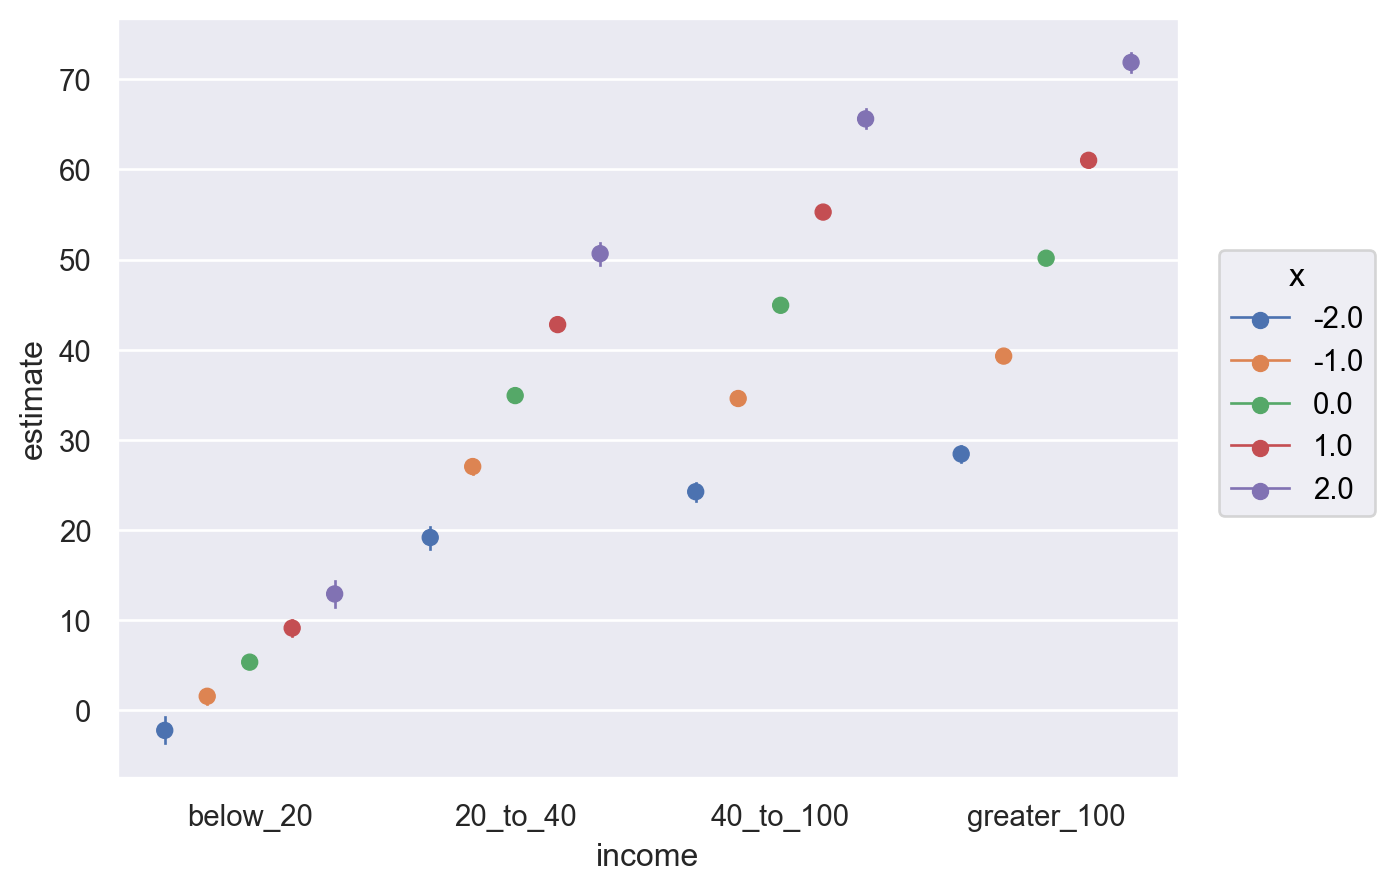

In [20]:
plot_predictions(
    model_int,
    idata_int,
    conditional={"income": levels, "x": np.linspace(-2, 2, 5)},
)

Each line corresponds to a value of `x`. At the highest value of `x`, the slope through the brackets is steeper than at the lowest, because the interaction amplifies the per-bracket effect.

## 7. Group-specific monotonic effects, `(mo(x) | g)`

When the monotonic slope varies by group, write it like any other group-specific term. The simplex is shared across groups (this matches brms), but each group gets its own slope offset $r_g$ with a hierarchical Normal/HalfNormal prior:

$$
r_g \sim \mathcal{N}(0, \sigma_g), \qquad \sigma_g \sim \text{HalfNormal}
$$

The total slope for group $g$ is $b + r_g$, where $b$ is the population-level slope.

In [21]:
g_levels = [f"g{i}" for i in range(1, 6)]
slope_per_group = {"g1": 1.0, "g2": 1.3, "g3": 0.7, "g4": 1.5, "g5": 0.5}

n_gs = 800
group = pd.Categorical(rng.choice(g_levels, n_gs), categories=g_levels)
income_gs = pd.Categorical(
    rng.choice(levels, n_gs), categories=levels, ordered=True
)
g_mult = np.array([slope_per_group[g] for g in group])
mu_gs = 5.0 + shape[income_gs.codes] * g_mult
y_gs = mu_gs + rng.normal(0, 3, n_gs)
data_gs = pd.DataFrame({"y": y_gs, "income": income_gs, "g": group})

model_gs = bmb.Model(
    "y ~ mo(income, id='inc') + (mo(income, id='inc') | g)",
    data_gs,
)
model_gs

       Formula: y ~ mo(income, id='inc') + (mo(income, id='inc') | g)
        Family: gaussian
          Link: mu = identity
  Observations: 800
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 34.4438, sigma: 52.7788)
        
        Group-level effects
            1|g ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 52.7788))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 21.1115)

We use `id='inc'` to share the simplex between the population-level term and the group-specific term. This matches the default brms behavior: groups can differ in the magnitude of the monotonic effect, but they share its shape.

In [22]:
idata_gs = model_gs.fit(
    draws=1000,
    tune=1000,
    chains=4,
    target_accept=0.95,
    random_seed=20260522,
    progressbar=False,
)
az.summary(
    idata_gs,
    var_names=[
        "Intercept",
        "mo(income, id='inc')_slope",
        "mo(income, id='inc')|g_sigma",
        "mo(income, id='inc')|g",
        "simplex_inc",
    ],
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, simplex_inc, mo(income, id='inc')_slope, mo(income, id='inc')|g_sigma, mo(income, id='inc')|g_offset, 1|g_sigma, 1|g_offset]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 17 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,4.71,0.49,4,5.4,1508,1327,1.00,0.014,0.019
"mo(income, id='inc')_slope",14.96,1.46,13,17,1478,1634,1.00,0.038,0.027
"mo(income, id='inc')|g_sigma",3.32,0.47,2.6,4.1,2331,2321,1.00,0.0095,0.0073
"mo(income, id='inc')|g[g1]",-0.03,1.46,-2.4,2.3,1472,1752,1.00,0.038,0.027
"mo(income, id='inc')|g[g2]",4.64,1.46,2.3,7,1479,1640,1.00,0.038,0.027
"mo(income, id='inc')|g[g3]",-4.37,1.46,-6.7,-2.1,1479,1699,1.00,0.038,0.027
"mo(income, id='inc')|g[g4]",7.56,1.46,5.2,9.9,1494,1672,1.00,0.038,0.027
"mo(income, id='inc')|g[g5]",-7.2,1.47,-9.6,-4.9,1484,1637,1.00,0.038,0.027
simplex_inc[20_to_40],0.6646,0.0054,0.66,0.67,4593,2809,1.00,8e-05,5.5e-05
simplex_inc[40_to_100],0.2259,0.0061,0.22,0.24,4532,3012,1.00,9e-05,6.5e-05


Per-group slope offsets, plotted on a forest:

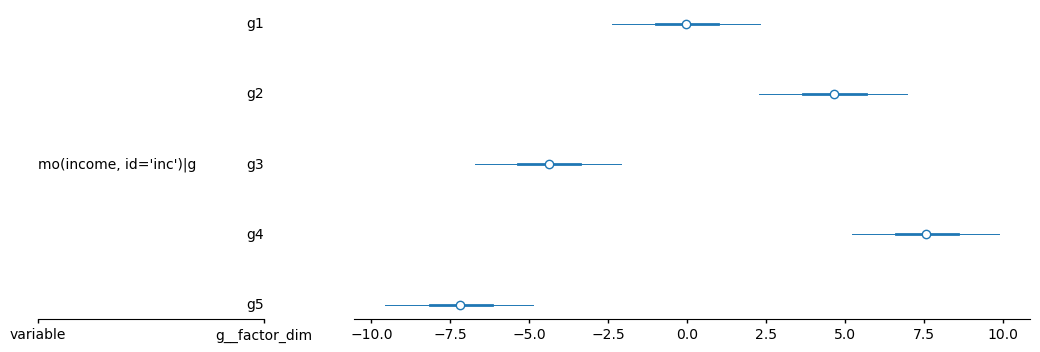

In [23]:
az.plot_forest(
    idata_gs,
    var_names=["mo(income, id='inc')|g"],
    combined=True,
);

The total slope for each group is the population slope plus its offset. We can extract that posterior and compare it against the truth.

In [24]:
post_gs = idata_gs.posterior
b_pop = post_gs["mo(income, id='inc')_slope"]
r_g = post_gs["mo(income, id='inc')|g"]
totals = (b_pop + r_g).mean(("chain", "draw")).to_numpy()
truth = np.array([slope_per_group[g] * 15 for g in g_levels])
pd.DataFrame(
    {
        "group": g_levels,
        "fitted_total_slope": totals.round(2),
        "true_total_slope": truth,
    }
)

,group,fitted_total_slope,true_total_slope
0,g1,14.94,15.0
1,g2,19.61,19.5
2,g3,10.59,10.5
3,g4,22.53,22.5
4,g5,7.77,7.5


## Summary

`mo()` gives you a principled way to model ordered predictors with unequal spacing using just two parameters per term. It composes with the rest of Bambi's machinery: distributional components, interactions, group-specific effects, custom priors, and shared simplices for conditional monotonicity.

Reach for `mo()` whenever an ordered predictor has more than three or four levels and you have no strong reason to assume the per-level increments are equal.

## References

* Bürkner, P.-C., and Charpentier, E. (2020). Modelling monotonic effects of ordinal predictors in Bayesian regression models. *British Journal of Mathematical and Statistical Psychology*, 73(3), 420-451. [doi:10.1111/bmsp.12195](https://doi.org/10.1111/bmsp.12195)
* brms `mo()` reference: [paulbuerkner.com/brms/reference/mo.html](https://paulbuerkner.com/brms/reference/mo.html)

In [25]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Fri, 22 May 2026

Python implementation: CPython
Python version       : 3.14.5
IPython version      : 9.13.0

arviz     : 1.1.0
bambi     : 0.18.1.dev1+gf359a0c47
matplotlib: 3.10.9
numpy     : 2.4.6
pandas    : 3.0.3

Watermark: 2.6.0

